# Problem Statement

The aim of this project is to build a machine learning model that predicts whether a loan application will be approved or rejectd. The prediction is based on applicaton information such as income, education, credit history, and loan amount

# Objective

Analyze the loan dataset

Perform data preprocessing

Build a machine learning model

Predict loan approval status

#  Dataset Description

* meaning of some independent variables

1. ApplicantIncome- monthly income of the person applying for the loan

2. CoapplicantIncome- income of the second person applying with the main applicant

3. LoanAmount- amount of money the person wants to borrow from the bank(In dataset if loanAmount = 500, it means 500k )

4. Loan_Amount_Term - the time period for repaying the loan(in dataset, if Loan_Amount_Term= 360, it means 360 months)

5. Credit_History- shows wheter the person has repaid loans properly in the past


In Loan_prediction dataset our target column(or dependent column) is loan_status

In [1]:
# Importing all libraries

#Basic libraries
import numpy as np
import pandas as pd
import seaborn as sb
import warnings
import matplotlib.pyplot as plt

#for skewness
from scipy.stats import skew

#for encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#for train and test
from sklearn.model_selection import train_test_split

#for model training
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Importing the data

loan_dataset = pd.read_csv('loan_prediction.csv')

In [3]:
# Understanding the data

In [4]:
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### Observation-

ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term and Credit_History are integer or float types, while other vairables are categorical type.

Gender, Married,dependents, Self_Employed, LoanAmount, Loan_Amount_Term and Credit_History have null values

In [5]:
loan_dataset.describe() 

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# EDA(Exploratory Data Ananlysis) part

### treating null values

In [6]:
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
warnings.filterwarnings('ignore')

In [8]:
# Filling null values in object type columns

In [9]:
loan_dataset['Gender'].fillna(loan_dataset['Gender'].mode()[0], inplace = True)
loan_dataset['Married'].fillna(loan_dataset['Married'].mode()[0], inplace = True)
loan_dataset['Dependents'].fillna(loan_dataset['Dependents'].mode()[0], inplace = True)
loan_dataset['Self_Employed'].fillna(loan_dataset['Self_Employed'].mode()[0], inplace = True)

In [10]:
loan_dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
loan_dataset['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [12]:
# Filling null values in integer and float type columns

In [13]:
loan_dataset['LoanAmount'].fillna(loan_dataset['LoanAmount'].median(), inplace= True)
loan_dataset['Loan_Amount_Term'].fillna(loan_dataset['Loan_Amount_Term'].median(), inplace = True)
loan_dataset['Credit_History'].fillna(loan_dataset['Credit_History'].mode()[0], inplace = True)

In [14]:
loan_dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [15]:
loan_dataset['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [16]:
#  Dependents column is shown as object type bcz of '+' sign

In [17]:
loan_dataset['Dependents'].replace('3+', 3, inplace = True)
loan_dataset['Dependents']= loan_dataset['Dependents'].astype(int)

In [18]:
loan_dataset['Dependents'].dtype

dtype('int64')

### Plotting graphs for all columns to check outliers

In [19]:
#for integer or float columns
int_col = [x for x in loan_dataset.columns if loan_dataset[x].dtype!= object]

In [20]:
int_col

['Dependents',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [21]:
loan_dataset.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


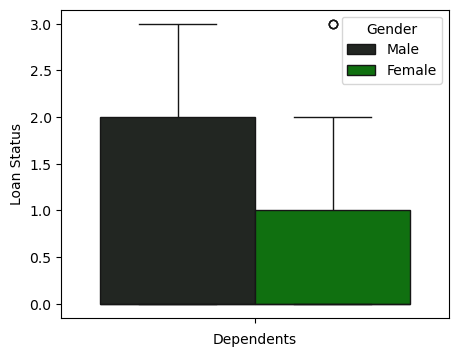

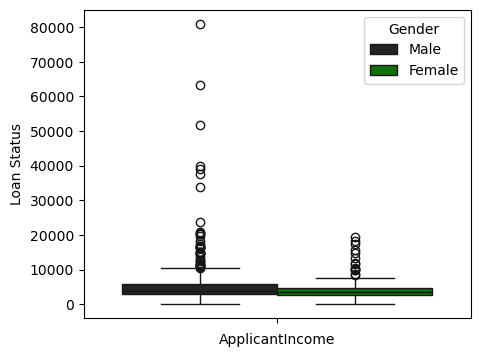

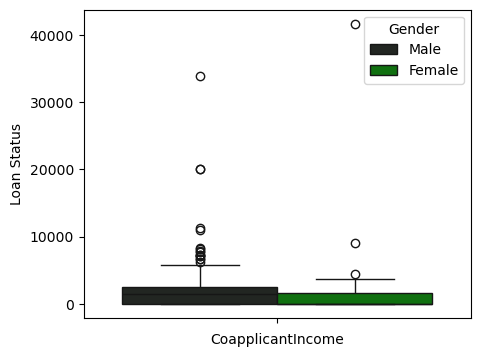

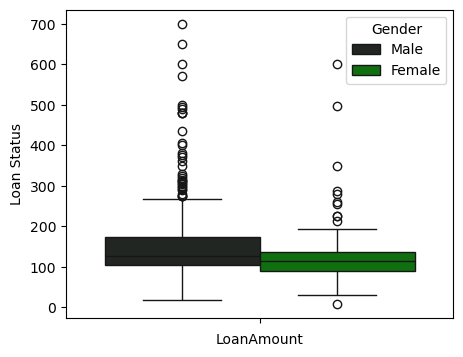

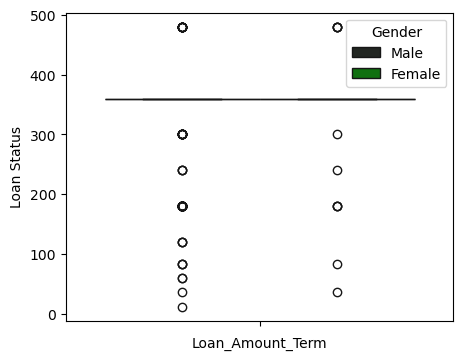

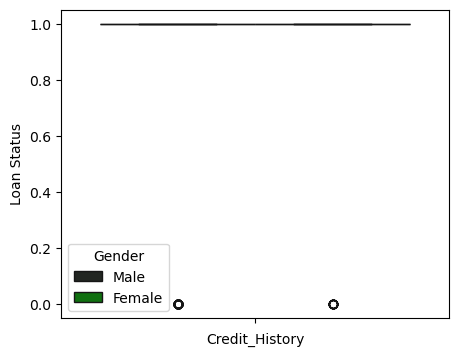

In [22]:
for plot in int_col:
    plt.figure(figsize= (5,4))
    sb.boxplot(y = loan_dataset[plot], color = 'g',hue = loan_dataset['Gender'])
    plt.ylabel('Loan Status')
    plt.xlabel(plot)
    plt.show()
    

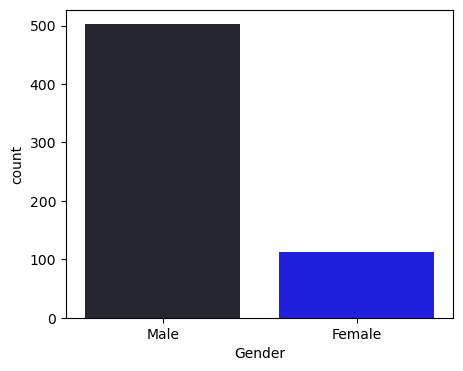

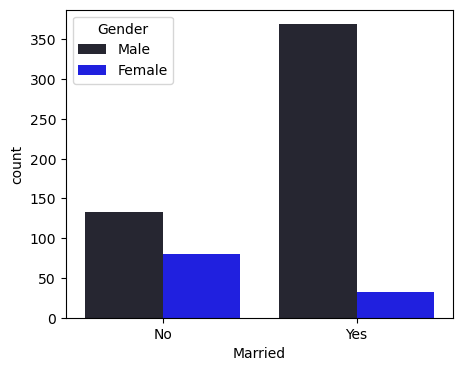

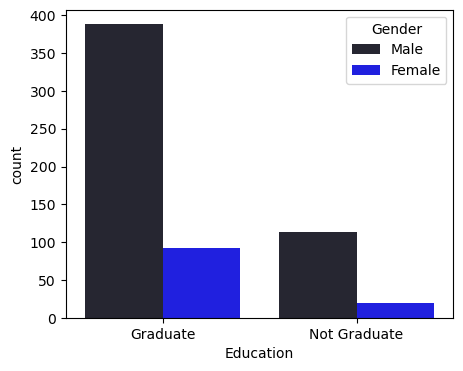

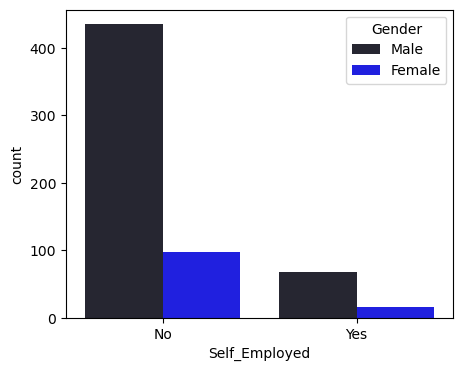

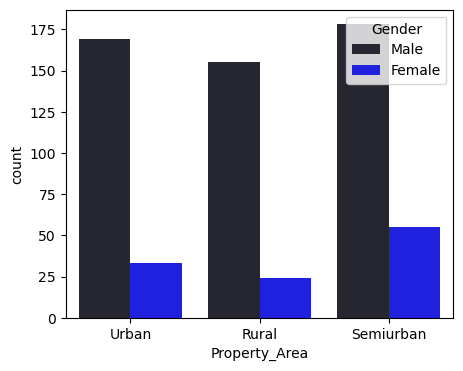

In [23]:
cat_clm = ['Gender','Married','Education','Self_Employed','Property_Area']
for y in cat_clm:
    plt.figure(figsize=(5,4))
    sb.countplot(x = y, hue= loan_dataset['Gender'], color = 'b', data = loan_dataset)
    plt.xlabel(y)
    
    

## Observation

There are some extreme high values in ApplicantIncome,CoapplicantIncome and LoanAmount column but we cant remove outliers from these column because it is  possible in real life cases.

Male has more counts for applying loan than Female

So we will not remove outliers form any column

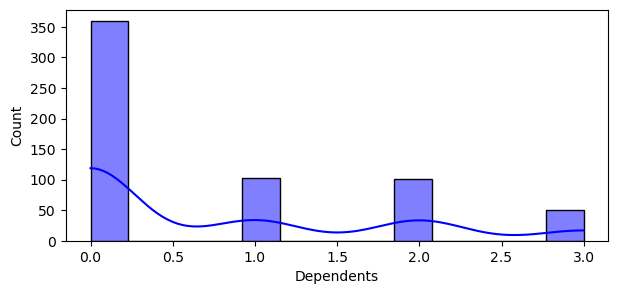

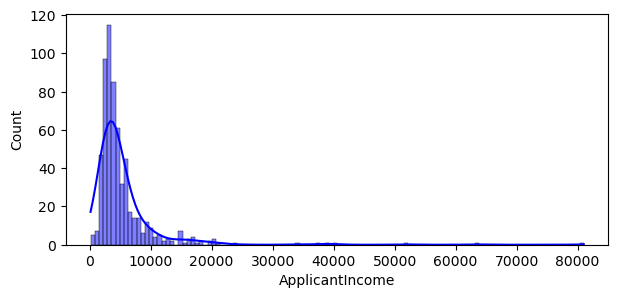

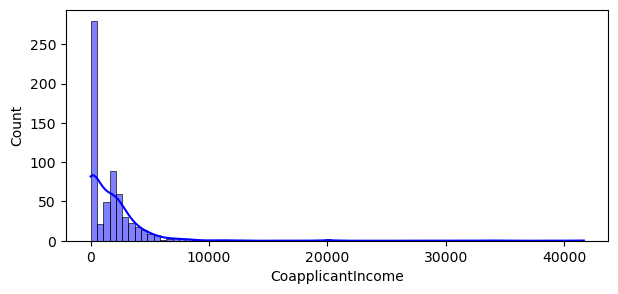

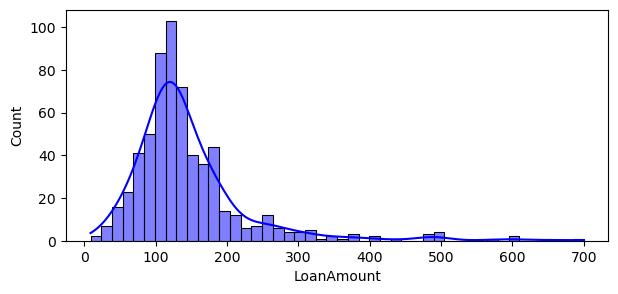

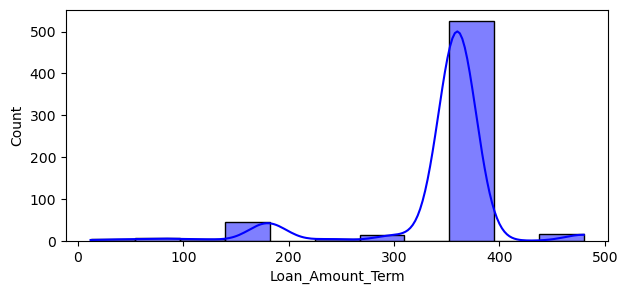

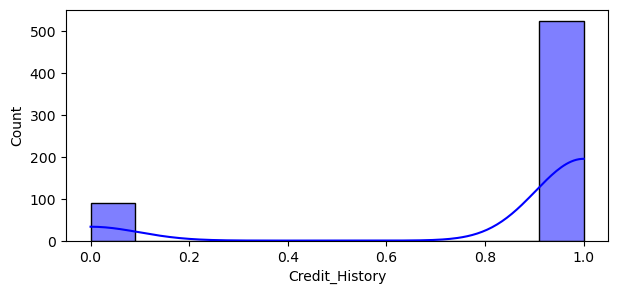

In [24]:
for z in loan_dataset.columns:
    if loan_dataset[z].dtype!= object:
        plt.figure(figsize= (7,3))
        sb.histplot(loan_dataset[z],kde= True, color = 'b')
        plt.show()

### Observations-

1. most of the Applicants hve 0 dependencies
2. Generally,most of the applicants have ApplicantIncome between 0 and 10,000
3. Most of the applicants have  0 coapplicantincome
4. Many applicants have taken loan between 0k and 200k
5. Many people have taken 360 month to repay the loan.
6. Most of the people have good credit History

# Skewness

In [25]:
loan_dataset[['Dependents', 'ApplicantIncome','CoapplicantIncome','LoanAmount', 'Loan_Amount_Term','Credit_History']].skew()

Dependents           1.015551
ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.743053
Loan_Amount_Term    -2.402112
Credit_History      -2.021971
dtype: float64

In [26]:
loan_dataset['ApplicantIncome'] = np.log(loan_dataset['ApplicantIncome'])
loan_dataset['CoapplicantIncome'] = np.log(loan_dataset['CoapplicantIncome'] + 1)
loan_dataset['LoanAmount'] = np.log(loan_dataset['LoanAmount'])

In [27]:
loan_dataset[['Dependents', 'ApplicantIncome','CoapplicantIncome','LoanAmount', 'Loan_Amount_Term','Credit_History']].skew()

Dependents           1.015551
ApplicantIncome      0.479580
CoapplicantIncome   -0.173073
LoanAmount          -0.195355
Loan_Amount_Term    -2.402112
Credit_History      -2.021971
dtype: float64

In [28]:
loan_dataset['CoapplicantIncome'].isnull().sum()

np.int64(0)

# Encoding 

In [29]:
#using LabelEncoder for gender, married, education and self-employed
# using One-Hot Encodr for Property_Area

In [30]:
le_encoder = LabelEncoder()
oh_encoder = OneHotEncoder()

#### For Property_Area

In [31]:
enc_pa = pd.get_dummies(loan_dataset.Property_Area, dtype= int)
enc_pa

,Rural,Semiurban,Urban
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
609,1,0,0
610,1,0,0
611,0,0,1
612,0,0,1


In [32]:
loan_dataset = pd.concat([loan_dataset, enc_pa], axis =1)

In [33]:
loan_dataset = loan_dataset.drop(['Property_Area','Rural'],axis= 'columns') # droping Rural column to reduce multicollinearity(dummy vairable trap) 

In [34]:
loan_dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Semiurban,Urban
0,LP001002,Male,No,0,Graduate,No,8.674026,0.000000,4.852030,360.0,1.0,Y,0,1
1,LP001003,Male,Yes,1,Graduate,No,8.430109,7.319202,4.852030,360.0,1.0,N,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,8.006368,0.000000,4.189655,360.0,1.0,Y,0,1
3,LP001006,Male,Yes,0,Not Graduate,No,7.856707,7.765993,4.787492,360.0,1.0,Y,0,1
4,LP001008,Male,No,0,Graduate,No,8.699515,0.000000,4.948760,360.0,1.0,Y,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,7.972466,0.000000,4.262680,360.0,1.0,Y,0,0
610,LP002979,Male,Yes,3,Graduate,No,8.320205,0.000000,3.688879,180.0,1.0,Y,0,0
611,LP002983,Male,Yes,1,Graduate,No,8.996157,5.484797,5.533389,360.0,1.0,Y,0,1
612,LP002984,Male,Yes,2,Graduate,No,8.933664,0.000000,5.231109,360.0,1.0,Y,0,1


### For gender, married, education and self-employed

In [35]:
ctg_col = [x for x in loan_dataset.columns if loan_dataset[x].dtype== object]
ctg_col

['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']

In [36]:
for clms in ctg_col:
    if clms!= 'Loan_ID':
        loan_dataset[clms]= le_encoder.fit_transform(loan_dataset[clms])

In [37]:
loan_dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Semiurban,Urban
0,LP001002,1,0,0,0,0,8.674026,0.000000,4.852030,360.0,1.0,1,0,1
1,LP001003,1,1,1,0,0,8.430109,7.319202,4.852030,360.0,1.0,0,0,0
2,LP001005,1,1,0,0,1,8.006368,0.000000,4.189655,360.0,1.0,1,0,1
3,LP001006,1,1,0,1,0,7.856707,7.765993,4.787492,360.0,1.0,1,0,1
4,LP001008,1,0,0,0,0,8.699515,0.000000,4.948760,360.0,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,7.972466,0.000000,4.262680,360.0,1.0,1,0,0
610,LP002979,1,1,3,0,0,8.320205,0.000000,3.688879,180.0,1.0,1,0,0
611,LP002983,1,1,1,0,0,8.996157,5.484797,5.533389,360.0,1.0,1,0,1
612,LP002984,1,1,2,0,0,8.933664,0.000000,5.231109,360.0,1.0,1,0,1


## Observation-

Male-1

female-0

yes-1

No-0

Graduate- 0

Not Graduate- 1

# Relation between Loan_Status and other columns

In [38]:
copy=loan_dataset.drop('Loan_ID', axis=1)

<Axes: >

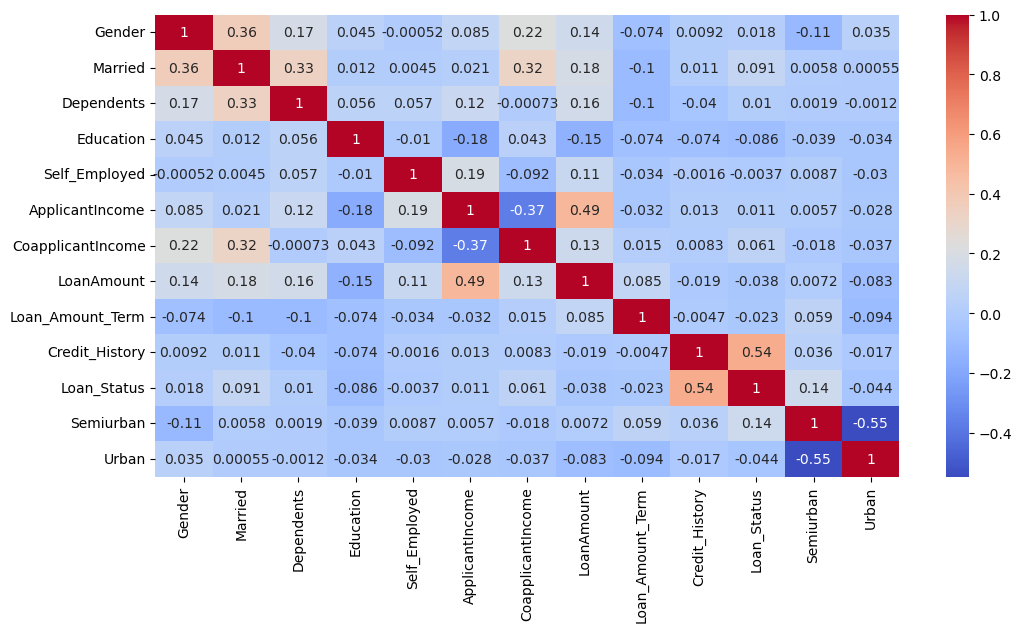

In [39]:
plt.figure(figsize= (12,6))
sb.heatmap(copy.corr(), annot= True,cmap= 'coolwarm')

## Observation-

Credit_History is very important column for our dataset. 

# Training and Testing our data

In [40]:
x = loan_dataset.drop(['Loan_ID','Loan_Status'], axis=1)
y= loan_dataset['Loan_Status']

In [41]:
x_train, x_test, y_train,y_test= train_test_split(x,y,test_size= 0.20,random_state= 42)

In [42]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 12)
(123, 12)
(491,)
(123,)


In [43]:
# Checking if loan_status balance or imbalance

loan_dataset['Loan_Status'].value_counts()
#Not much imbalance so we dont have to SMOTE

Loan_Status
1    422
0    192
Name: count, dtype: int64

# Model Training

In [44]:
lr = LogisticRegression()

In [45]:
lr.fit(x_train, y_train)

LogisticRegression()

In [46]:
y_pred = lr.predict(x_test)

In [47]:
testing_accuracy = accuracy_score(y_test,y_pred)

In [48]:
lr_model_accuracy= accuracy*100
'Accuray of our logistic Regression Model', lr_model_accuracy

NameError: name 'accuracy' is not defined

In [ ]:
sb.heatmap(confusion_matrix(y_test, y_pred), annot= True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

## Result

The Logisitic Regression Model achieved an accuracy of 78.86.